# 🏴‍☠️ JackSparrow Trading Bot — v22
**Delta Exchange India | ML-Driven Futures Bot**

## Architecture
- **Data**: 5m + 15m OHLCV fetched directly from Delta Exchange India REST API
- **ML Models**: LightGBM + RandomForest ensemble with walk-forward retraining
- **Backtesting**: Walk-forward OOS with transaction costs, slippage, and no lookahead bias
- **Live Trading**: Periodic retraining scheduler + signal-based order execution

## Changelog v22
- Fixed 15m candle fetching to use Delta Exchange API directly (was derived from 5m)
- Fixed data leakage in feature engineering (shift applied correctly)
- Replaced simple train/test split with walk-forward cross-validation
- Added slippage + fee model to backtester
- Added ensemble voting for signal generation
- Added live retraining scheduler with configurable frequency
- Added position sizing via Kelly Criterion (fractional)
- Fixed NaN handling in feature pipeline
- **Data integrity**: Optional `validate_candles` is now resolved from the repo; `STRICT_CANDLES` + retried pagination for full history fetches


## Runtime order (run cells top to bottom)

1. **Config** — Sets `SYMBOL_5M` / `SYMBOL_15M` (Delta India futures symbols, default `BTCUSD`), `WARMUP_CANDLES`, paths, and `ALLOW_SYNTHETIC_DATA`.
2. **Delta client** — Defines `DeltaClient` (retried HTTP + `validate_candles` from `TRADING_AGENT_ROOT` or repo checkout). Default **STRICT_CANDLES** aborts if validation cannot run or candles have gaps; use `STRICT_CANDLES=0` only for dev. Empty API results **raise**.
3. **Synthetic generator** (optional) — Only if you may use synthetic OHLCV: run the cell that defines `generate_synthetic_candles` **before** the fetch cell when `ALLOW_SYNTHETIC_DATA=1`.
4. **Fetch 5m / 15m** — Calls the API; on empty data, either raises or uses synthetic only when allowed above.
5. **Features → model → backtest** — Depends on valid `df_5m` / `df_15m` from step 4.

### Data integrity (v22 audit)
- **STRICT_CANDLES** (default on): loads `agent.data.candle_validation` from `TRADING_AGENT_ROOT` or the working tree; enforces regular bar spacing and OHLC sanity. Training aborts if the fetch is incomplete or gaps exist.
- **15m data** is fetched from the API directly (not resampled from 5m).
- **Production v15 agent** still needs a separate export/bridge — this notebook trains a different ensemble format.


## Production agent alignment (v15 / `MODEL_DIR`)

This notebook trains a **LightGBM + RandomForest** ensemble and saves under `MODEL_DIR`. The live trading agent in this repo loads **JackSparrow v15** artifacts: **XGBoost** pipelines bundled with `metadata_{SYMBOL}_{timeframe}.json` (e.g. `metadata_BTCUSD_5m.json`) and `pipeline_{timeframe}_latest.pkl` or `pipeline_{timeframe}_active.json` beside that metadata.

- **Discovery**: see `agent/models/model_discovery.py` and `agent/models/pipeline_v15_node.py`.
- **Features at runtime**: `feature_store/v15_feature_compute.py` (`build_v15_feature_dict_for_tf`) — not identical to `compute_features_5m` / `compute_features_15m` in this notebook.
- **To ship a v15-compatible model**, use the Colab training notebooks that export the v15 pipeline (e.g. `JackSparrow_Training_Colab_v16.ipynb` / v17) or align exports manually: feature list + `train_median` in metadata + joblib bundle shape expected by `PipelineV15Node`.

Do not assume this notebook’s ensemble pickle is directly loadable by the agent without an export/bridge step.


## 📦 Cell 1 — Install Dependencies

In [1]:
!pip install -q lightgbm scikit-learn pandas numpy requests python-dotenv schedule ta joblib pyarrow

  Preparing metadata (setup.py) ... done


## ⚙️ Cell 2 — Configuration

In [2]:
import os

# ── Delta Exchange India Credentials ────────────────────────────────────────
# Set these as Colab Secrets (left sidebar 🔑) or environment variables
try:
    from google.colab import userdata
    API_KEY    = userdata.get('DELTA_API_KEY')
    API_SECRET = userdata.get('DELTA_API_SECRET')
except Exception:
    API_KEY    = os.getenv('DELTA_API_KEY', 'YOUR_KEY_HERE')
    API_SECRET = os.getenv('DELTA_API_SECRET', 'YOUR_SECRET_HERE')

# ── Exchange Config ──────────────────────────────────────────────────────────
BASE_URL       = 'https://api.india.delta.exchange'   # Delta Exchange India
SYMBOL_5M      = 'BTCUSD'                            # Futures product symbol
SYMBOL_15M     = 'BTCUSD'                            # Same symbol, different resolution
PRODUCT_ID     = 27                                   # BTC perpetual product_id on Delta India

# ── Data Config ─────────────────────────────────────────────────────────────
CANDLE_RES_5M  = '5m'
CANDLE_RES_15M = '15m'
LOOKBACK_DAYS  = 90                                   # Days of history to fetch
WARMUP_CANDLES = 50                                   # Candles needed for indicator warmup

# ── ML Config ───────────────────────────────────────────────────────────────
RETRAIN_INTERVAL_MINUTES = 60                         # How often to retrain models live
MIN_TRAIN_SAMPLES        = 500                        # Min rows before training
WALK_FORWARD_SPLITS      = 5                          # Number of WF folds
SIGNAL_THRESHOLD         = 0.58                       # Probability threshold for entry
ENSEMBLE_WEIGHTS         = {'lgbm': 0.6, 'rf': 0.4}  # Ensemble vote weights

# ── Trade Config ────────────────────────────────────────────────────────────
CAPITAL_USDT             = 1000.0                     # Starting capital
MAKER_FEE                = 0.0005                     # 0.05% maker fee
TAKER_FEE                = 0.0005                     # 0.05% taker fee (Delta India flat)
SLIPPAGE_PCT             = 0.0003                     # 0.03% slippage estimate
MAX_POSITION_PCT         = 0.20                       # Max 20% capital per trade (Kelly cap)
STOP_LOSS_PCT            = 0.015                      # 1.5% SL
TAKE_PROFIT_PCT          = 0.03                       # 3.0% TP  (2:1 R/R)
LEVERAGE                 = 5                          # Futures leverage

# ── Backtest Config ─────────────────────────────────────────────────────────
BACKTEST_DAYS            = 60                         # Days for OOS backtest
MODEL_DIR                = '/content/models'          # Model save path
os.makedirs(MODEL_DIR, exist_ok=True)

# Production default: never use synthetic OHLCV. Set ALLOW_SYNTHETIC_DATA=1 for local dev only.
ALLOW_SYNTHETIC_DATA = os.getenv('ALLOW_SYNTHETIC_DATA', '0') == '1'
TRADING_AGENT_ROOT = os.getenv('TRADING_AGENT_ROOT', '').strip()
if TRADING_AGENT_ROOT:
    import sys
    from pathlib import Path as _Path
    _rp = _Path(TRADING_AGENT_ROOT).resolve()
    if str(_rp) not in sys.path:
        sys.path.insert(0, str(_rp))

# Candle integrity: requires agent.data.candle_validation (set TRADING_AGENT_ROOT). STRICT_CANDLES=0 only for dev.
STRICT_CANDLES = os.getenv('STRICT_CANDLES', '1') != '0'
FETCH_PAGE_RETRIES = int(os.getenv('FETCH_PAGE_RETRIES', '3'))

print('✅ Config loaded')
print(f'   Symbol: {SYMBOL_5M} | Leverage: {LEVERAGE}x | Capital: ${CAPITAL_USDT}')
print(f'   Signal threshold: {SIGNAL_THRESHOLD} | Retrain every: {RETRAIN_INTERVAL_MINUTES}m')
print(f'   STRICT_CANDLES={STRICT_CANDLES} | FETCH_PAGE_RETRIES={FETCH_PAGE_RETRIES}')

✅ Config loaded
   Symbol: BTCUSD | Leverage: 5x | Capital: $1000.0
   Signal threshold: 0.58 | Retrain every: 60m


## 🌐 Cell 3 — Delta Exchange API Client
> Both 5m and 15m candles are fetched directly from Delta Exchange India REST API  
> using the `/v2/history/candles` endpoint with the respective `resolution` parameter.

In [3]:
import time
import hmac
import hashlib
import os
import sys
import requests
import pandas as pd
import numpy as np
from pathlib import Path as _Path
from datetime import datetime, timezone, timedelta
from typing import Optional

validate_candles = None
try:
    from agent.data.candle_validation import validate_candles
except ImportError:
    pass


def _resolve_validate_candles():
    """Load validate_candles from repo (TRADING_AGENT_ROOT or cwd parents)."""
    global validate_candles
    if validate_candles is not None:
        return validate_candles
    roots = []
    r = os.environ.get("TRADING_AGENT_ROOT", "").strip()
    if r:
        roots.append(_Path(r).resolve())
    here = _Path.cwd().resolve()
    for p in (here, here.parent, here.parent.parent):
        roots.append(p)
    seen = set()
    for base in roots:
        if base in seen:
            continue
        seen.add(base)
        if not base.exists():
            continue
        mod = base / "agent" / "data" / "candle_validation.py"
        if mod.is_file():
            s = str(base)
            if s not in sys.path:
                sys.path.insert(0, s)
            try:
                from agent.data.candle_validation import validate_candles as vc
                return vc
            except ImportError:
                pass
    return None


validate_candles = _resolve_validate_candles()
if STRICT_CANDLES and validate_candles is None:
    raise ImportError(
        "STRICT_CANDLES=True but agent.data.candle_validation could not be imported. "
        "Set environment TRADING_AGENT_ROOT to your Trading Agent repo root, or run the notebook from that checkout."
    )
elif validate_candles is None:
    print(
        "WARNING: validate_candles unavailable — no gap/regularity OHLC checks. "
        "Set TRADING_AGENT_ROOT or STRICT_CANDLES=0 (not recommended)."
    )


def _validate_frame(df: pd.DataFrame, resolution: str, min_rows: int) -> None:
    if validate_candles is None:
        return
    validate_candles(
        df,
        resolution,
        min_rows=min_rows,
        allow_last_irregular=True,
    )


class DeltaClient:
    """
    Minimal Delta Exchange India REST client.
    Candle endpoint: GET /v2/history/candles
    Docs: https://docs.delta.exchange/#get-ohlcv-candles

    [v22-enhanced] Added fetch_latest_candles() for incremental data updates (v16 pattern)
    """

    VALID_RESOLUTIONS = {'1m', '3m', '5m', '15m', '30m', '1h', '2h', '4h', '6h', '1d', '1w'}

    def __init__(self, base_url: str, api_key: str, api_secret: str):
        self.base_url   = base_url.rstrip('/')
        self.api_key    = api_key
        self.api_secret = api_secret
        self.session    = requests.Session()
        self.session.headers.update({
            'Content-Type': 'application/json',
            'api-key': self.api_key,
        })

    def _sign(self, method: str, path: str, query: str = '', body: str = '') -> dict:
        ts      = str(int(time.time()))
        message = method.upper() + ts + path + query + body
        sig     = hmac.new(
            self.api_secret.encode(), message.encode(), hashlib.sha256
        ).hexdigest()
        return {'timestamp': ts, 'signature': sig}

    def _get(self, path: str, params: dict = None, signed: bool = False) -> dict:
        url      = self.base_url + path
        params   = params or {}
        query_str = '&'.join(f'{k}={v}' for k, v in sorted(params.items()))
        headers  = {}
        if signed:
            auth = self._sign('GET', path, '?' + query_str if query_str else '')
            headers = {'timestamp': auth['timestamp'], 'signature': auth['signature']}
        resp = self.session.get(url, params=params, headers=headers, timeout=10)
        resp.raise_for_status()
        return resp.json()

    def _get_json_retry(self, path: str, params: dict = None, signed: bool = False) -> dict:
        last_err = None
        for attempt in range(FETCH_PAGE_RETRIES):
            try:
                return self._get(path, params, signed)
            except (requests.HTTPError, requests.ConnectionError, requests.Timeout) as e:
                last_err = e
                if attempt + 1 < FETCH_PAGE_RETRIES:
                    time.sleep(0.4 * (2 ** attempt))
        assert last_err is not None
        raise last_err

    def fetch_candles(
        self,
        symbol: str,
        resolution: str,
        start_time: Optional[datetime] = None,
        end_time: Optional[datetime]   = None,
        lookback_days: int             = 30,
    ) -> pd.DataFrame:
        if resolution not in self.VALID_RESOLUTIONS:
            raise ValueError(f'Invalid resolution: {resolution}. '
                             f'Valid: {self.VALID_RESOLUTIONS}')

        if end_time is None:
            end_time = datetime.now(timezone.utc)
        if start_time is None:
            start_time = end_time - timedelta(days=lookback_days)

        t_end   = int(end_time.timestamp())
        t_start = int(start_time.timestamp())

        res_map = {
            '1m': 60, '3m': 180, '5m': 300, '15m': 900,
            '30m': 1800, '1h': 3600, '2h': 7200, '4h': 14400,
            '6h': 21600, '1d': 86400, '1w': 604800,
        }
        res_secs  = res_map[resolution]
        page_size = 500

        all_candles = []
        cursor_end  = t_end
        pagination_failed = False

        print(f'  Fetching {resolution} candles for {symbol} '
              f'[{start_time.date()} → {end_time.date()}] ...')

        while cursor_end > t_start:
            cursor_start = max(t_start, cursor_end - res_secs * page_size)
            params = {
                'symbol':     symbol,
                'resolution': resolution,
                'start':      cursor_start,
                'end':        cursor_end,
            }
            try:
                data = self._get_json_retry('/v2/history/candles', params=params)
            except (requests.HTTPError, requests.ConnectionError, requests.Timeout) as e:
                if STRICT_CANDLES:
                    raise RuntimeError(
                        f'Candle pagination failed after {FETCH_PAGE_RETRIES} retries: {e}'
                    ) from e
                print(f'  ⚠️  HTTP error fetching candles (giving up this window): {e}')
                pagination_failed = True
                break

            candles = data.get('result', [])
            if not candles:
                break

            all_candles.extend(candles)
            cursor_end = cursor_start - 1
            time.sleep(0.15)

        if not all_candles:
            raise ValueError(
                f'Incomplete candle data: no rows returned for {symbol} {resolution}'
            )

        if pagination_failed and STRICT_CANDLES:
            raise RuntimeError(
                'Incomplete candle fetch: pagination stopped early (HTTP/network). '
                'Fix connectivity or set STRICT_CANDLES=0 to use partial data (not recommended).'
            )

        df = pd.DataFrame(all_candles)
        df = df.rename(columns={
            'time': 'timestamp', 'o': 'open', 'h': 'high',
            'l': 'low',          'c': 'close', 'v': 'volume',
        })
        for col in ['open', 'high', 'low', 'close', 'volume']:
            if col not in df.columns:
                letter = col[0]
                if letter in df.columns:
                    df[col] = df[letter]

        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
        df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]
        df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
        df[['open', 'high', 'low', 'close', 'volume']] = \
            df[['open', 'high', 'low', 'close', 'volume']].astype(float)

        span_req = max(0, t_end - t_start)
        span_got = (df.timestamp.iloc[-1] - df.timestamp.iloc[0]).total_seconds()
        print(f'  ✅ {len(df)} {resolution} candles | '
              f'{df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()}')
        print(f'     span(requested window)≈{span_req/86400:.2f}d  span(data)≈{span_got/86400:.2f}d')

        _validate_frame(df, resolution, min_rows=max(WARMUP_CANDLES, 50))
        return df

    def fetch_latest_candles(
        self,
        symbol: str,
        resolution: str,
        n_bars: int = 5000,
    ) -> pd.DataFrame:
        if resolution not in self.VALID_RESOLUTIONS:
            raise ValueError(f'Invalid resolution: {resolution}')

        res_map = {
            '1m': 60, '3m': 180, '5m': 300, '15m': 900,
            '30m': 1800, '1h': 3600, '2h': 7200, '4h': 14400,
            '6h': 21600, '1d': 86400, '1w': 604800,
        }
        res_secs = res_map[resolution]
        now_ts   = int(time.time())
        end_ts   = now_ts - res_secs
        start_ts = end_ts - (n_bars * res_secs * 1.05)

        params = {
            'symbol':     symbol,
            'resolution': resolution,
            'start':      int(start_ts),
            'end':        int(end_ts),
        }

        try:
            data = self._get_json_retry('/v2/history/candles', params=params)
            candles = data.get('result', [])
            if not candles:
                raise ValueError(
                    f'Incomplete incremental candle data for {symbol} {resolution}'
                )

            df = pd.DataFrame(candles)
            df = df.rename(columns={
                'time': 'timestamp', 'o': 'open', 'h': 'high',
                'l': 'low', 'c': 'close', 'v': 'volume',
            })
            for col in ['open', 'high', 'low', 'close', 'volume']:
                if col not in df.columns and col[0] in df.columns:
                    df[col] = df[col[0]]

            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
            df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]
            df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
            df[['open', 'high', 'low', 'close', 'volume']] = \
                df[['open', 'high', 'low', 'close', 'volume']].astype(float)

            out = df.tail(n_bars)
            print(f'  ✅ Incremental {resolution}: fetched {len(df):,} → latest {len(out):,}')
            if len(out) > 0:
                _validate_frame(out, resolution, min_rows=min(len(out), max(WARMUP_CANDLES, 20)))
            return out

        except Exception as e:
            raise RuntimeError(f'Incremental fetch failed: {e}') from e

    def get_balance(self) -> float:
        data = self._get('/v2/wallet/balances', signed=True)
        for asset in data.get('result', []):
            if asset.get('asset_symbol') == 'USDT':
                return float(asset.get('available_balance', 0))
        return 0.0

    def get_ticker(self, symbol: str) -> float:
        data = self._get(f'/v2/tickers/{symbol}')
        return float(data['result']['close'])

    def place_order(
        self, symbol: str, side: str, size: float,
        order_type: str = 'market_order'
    ) -> dict:
        import json
        path   = '/v2/orders'
        payload = {
            'product_symbol': symbol,
            'side':           side,
            'size':           int(size),
            'order_type':     order_type,
        }
        body  = json.dumps(payload, separators=(',', ':'))
        ts    = str(int(time.time()))
        msg   = f'POST{ts}{path}{body}'
        sig   = hmac.new(
            self.api_secret.encode(), msg.encode(), hashlib.sha256
        ).hexdigest()
        headers = {'timestamp': ts, 'signature': sig}
        resp  = self.session.post(
            self.base_url + path, data=body, headers=headers, timeout=10
        )
        resp.raise_for_status()
        return resp.json()


client = DeltaClient(BASE_URL, API_KEY, API_SECRET)
print('✅ DeltaClient ready (v22: validated candles + retry pagination)')



✅ DeltaClient ready (v22-enhanced with incremental fetch)


## 📊 Cell 4 — Fetch 5m & 15m Candles
> Both timeframes are fetched **independently and directly** from Delta Exchange India.  
> 15m candles are NOT derived by resampling 5m data.

In [4]:
print('📡 Fetching candles from Delta Exchange India ...')

try:
    # ── 5m Candles ──────────────────────────────────────────────────────────
    df_5m = client.fetch_candles(
        symbol       = SYMBOL_5M,
        resolution   = CANDLE_RES_5M,
        lookback_days= LOOKBACK_DAYS,
    )
    # ── 15m Candles (direct API fetch, NOT resampled from 5m) ───────────────
    df_15m = client.fetch_candles(
        symbol       = SYMBOL_15M,
        resolution   = CANDLE_RES_15M,
        lookback_days= LOOKBACK_DAYS,
    )
except Exception as e:
    print(f'❌ Strict candle fetch failed: {e}')
    df_5m, df_15m = pd.DataFrame(), pd.DataFrame()

if df_5m.empty or df_15m.empty:
    if ALLOW_SYNTHETIC_DATA:
        gen = globals().get('generate_synthetic_candles')
        if gen is None:
            raise RuntimeError(
                'ALLOW_SYNTHETIC_DATA=1 but generate_synthetic_candles is not defined — '
                'run the synthetic-generator cell below first.'
            )
        print('\n⚠️  API returned no data — ALLOW_SYNTHETIC_DATA=1: using dev-only synthetic OHLCV.\n')
        df_5m = gen('BTCUSD', '5m', lookback_days=LOOKBACK_DAYS)
        df_15m = gen('BTCUSD', '15m', lookback_days=LOOKBACK_DAYS)
    else:
        raise ValueError(
            'No candle data from Delta API. Fix credentials/symbol or set ALLOW_SYNTHETIC_DATA=1 '
            '(development only).'
        )

print(f'\n5m  shape : {df_5m.shape}')
print(f'15m shape : {df_15m.shape}')
df_5m.tail(3)

📡 Fetching candles from Delta Exchange India ...
  Fetching 5m candles for BTCUSD [2026-01-18 → 2026-04-18] ...
  ✅ 25909 5m candles | 2026-01-18 → 2026-04-18
  Fetching 15m candles for BTCUSD [2026-01-18 → 2026-04-18] ...
  ✅ 8640 15m candles | 2026-01-18 → 2026-04-18

5m  shape : (25909, 6)
15m shape : (8640, 6)


,timestamp,open,high,low,close,volume
25906,2026-04-18 09:40:00+00:00,76569.5,76600.0,76569.5,76589.5,18005.0
25907,2026-04-18 09:45:00+00:00,76589.5,76663.5,76567.5,76631.0,41557.0
25908,2026-04-18 09:50:00+00:00,76631.5,76631.5,76532.0,76532.0,32350.0


In [5]:
# Synthetic fallback is handled in the fetch cell above (strict by default).
# When ALLOW_SYNTHETIC_DATA=1, run the next cell first to define generate_synthetic_candles.
pass


In [6]:
# ── Synthetic Data Generator (for testing without live API) ─────────────────
def generate_synthetic_candles(symbol: str, resolution: str, lookback_days: int = 90) -> pd.DataFrame:
    """
    Generate realistic synthetic OHLCV data for testing.
    Simulates BTC price movement with volatility and trends.
    """
    n_candles = lookback_days * 24 * 60 // int(resolution.replace('m', '').replace('h', ''))

    # Generate timestamps
    end_time = datetime.now(timezone.utc)
    res_minutes = int(resolution.replace('m', '').replace('h', '')) if 'm' in resolution else int(resolution.replace('h', '')) * 60
    timestamps = [end_time - timedelta(minutes=i*res_minutes) for i in range(n_candles)]
    timestamps.reverse()

    # Synthetic price: random walk with drift
    np.random.seed(42)
    price = 42000  # Starting BTC price
    prices = [price]
    for _ in range(n_candles - 1):
        drift = 0.0005
        volatility = 0.012
        price += price * (drift + volatility * np.random.randn())
        prices.append(max(price, 1000))  # Floor at 1000

    # OHLCV from close prices
    data = []
    for i, ts in enumerate(timestamps):
        close_price = prices[i]
        open_price = close_price * (1 + np.random.randn() * 0.002)
        high_price = max(open_price, close_price) * (1 + abs(np.random.randn()) * 0.005)
        low_price = min(open_price, close_price) * (1 - abs(np.random.randn()) * 0.005)
        volume = np.random.uniform(100, 10000)

        data.append({
            'timestamp': ts,
            'open': open_price,
            'high': high_price,
            'low': low_price,
            'close': close_price,
            'volume': volume,
        })

    return pd.DataFrame(data)

print('✅ Synthetic data generator ready')

✅ Synthetic data generator ready


In [7]:
# ── Debug API Call ──────────────────────────────────────────────────────────
print('🔍 Debugging API call...')
print(f'API_KEY: {API_KEY[:20] if len(API_KEY) > 20 else API_KEY}')
print(f'API_SECRET: {API_SECRET[:20] if len(API_SECRET) > 20 else API_SECRET}')
print(f'BASE_URL: {BASE_URL}')

# Try a raw API call with debug info
import json
test_params = {
    'symbol': SYMBOL_5M,
    'resolution': '5m',
    'start': int((datetime.now(timezone.utc) - timedelta(days=1)).timestamp()),
    'end': int(datetime.now(timezone.utc).timestamp()),
}
print(f'\nTest params: {test_params}')
print(f'Time range: {datetime.fromtimestamp(test_params["start"], tz=timezone.utc)} → {datetime.fromtimestamp(test_params["end"], tz=timezone.utc)}')

try:
    response = client._get('/v2/history/candles', params=test_params)
    print(f'\n✅ API Response received')
    print(f'Response keys: {list(response.keys())}')
    if 'result' in response:
        result = response['result']
        print(f'Result type: {type(result).__name__}')
        if isinstance(result, list):
            print(f'Result length: {len(result)}')
            if len(result) > 0:
                print(f'First candle: {result[0]}')
                print(f'First candle keys: {list(result[0].keys())}')
        elif isinstance(result, dict):
            print(f'Result dict: {result}')
    if 'status' in response:
        print(f'Status: {response["status"]}')
    if 'message' in response:
        print(f'Message: {response["message"]}')
    print(f'\nFull response (first 800 chars):\n{json.dumps(response, indent=2)[:800]}')
except requests.HTTPError as e:
    print(f'❌ HTTP Error: {e}')
    print(f'Response text: {e.response.text[:500]}')
except Exception as e:
    print(f'❌ Error: {type(e).__name__}: {e}')

🔍 Debugging API call...
API_KEY: SittsaP5U0jQG5McOhJ2
API_SECRET: hUjO6R0zBHRGFIMvyfGB
BASE_URL: https://api.india.delta.exchange

Test params: {'symbol': 'BTCUSD', 'resolution': '5m', 'start': 1776419690, 'end': 1776506090}
Time range: 2026-04-17 09:54:50+00:00 → 2026-04-18 09:54:50+00:00

✅ API Response received
Response keys: ['result', 'success']
Result type: list
Result length: 288
First candle: {'close': 76532, 'high': 76631.5, 'low': 76532, 'open': 76631.5, 'time': 1776505800, 'volume': 32350}
First candle keys: ['close', 'high', 'low', 'open', 'time', 'volume']

Full response (first 800 chars):
{
  "result": [
    {
      "close": 76532,
      "high": 76631.5,
      "low": 76532,
      "open": 76631.5,
      "time": 1776505800,
      "volume": 32350
    },
    {
      "close": 76631,
      "high": 76663.5,
      "low": 76567.5,
      "open": 76589.5,
      "time": 1776505500,
      "volume": 41557
    },
    {
      "close": 76589.5,
      "high": 76600,
      "low": 76569.5,
 

## 🔧 Cell 5 — Feature Engineering
> **No lookahead bias**: all features are computed using `.shift(1)` where necessary.  
> 15m features are merged onto the 5m frame using `merge_asof` (backward fill, no future data).

In [8]:
import pandas as pd
import numpy as np


def compute_features_5m(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute technical features on 5m OHLCV data.
    All rolling/shift operations use only past data.
    """
    d = df.copy()

    # ── Price-derived ────────────────────────────────────────────────────────
    d['ret_1']  = d['close'].pct_change(1)
    d['ret_3']  = d['close'].pct_change(3)
    d['ret_6']  = d['close'].pct_change(6)
    d['ret_12'] = d['close'].pct_change(12)

    # ── Moving Averages ──────────────────────────────────────────────────────
    d['ema_9']  = d['close'].ewm(span=9,  adjust=False).mean()
    d['ema_21'] = d['close'].ewm(span=21, adjust=False).mean()
    d['ema_50'] = d['close'].ewm(span=50, adjust=False).mean()
    d['ema_9_21_cross'] = (d['ema_9'] - d['ema_21']) / d['ema_21']
    d['price_ema21']    = (d['close'] - d['ema_21']) / d['ema_21']

    # ── RSI ──────────────────────────────────────────────────────────────────
    def rsi(series, period=14):
        delta = series.diff()
        gain  = delta.where(delta > 0, 0.0).ewm(alpha=1/period, adjust=False).mean()
        loss  = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/period, adjust=False).mean()
        rs    = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))

    d['rsi_14'] = rsi(d['close'], 14)
    d['rsi_7']  = rsi(d['close'], 7)

    # ── MACD ─────────────────────────────────────────────────────────────────
    ema12 = d['close'].ewm(span=12, adjust=False).mean()
    ema26 = d['close'].ewm(span=26, adjust=False).mean()
    d['macd']        = ema12 - ema26
    d['macd_signal'] = d['macd'].ewm(span=9, adjust=False).mean()
    d['macd_hist']   = d['macd'] - d['macd_signal']

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    bb_mid       = d['close'].rolling(20).mean()
    bb_std       = d['close'].rolling(20).std()
    d['bb_upper'] = bb_mid + 2 * bb_std
    d['bb_lower'] = bb_mid - 2 * bb_std
    d['bb_width'] = (d['bb_upper'] - d['bb_lower']) / (bb_mid + 1e-9)
    d['bb_pos']   = (d['close'] - d['bb_lower']) / (d['bb_upper'] - d['bb_lower'] + 1e-9)

    # ── ATR ──────────────────────────────────────────────────────────────────
    tr = pd.concat([
        d['high'] - d['low'],
        (d['high'] - d['close'].shift(1)).abs(),
        (d['low']  - d['close'].shift(1)).abs(),
    ], axis=1).max(axis=1)
    d['atr_14'] = tr.ewm(span=14, adjust=False).mean()
    d['atr_pct'] = d['atr_14'] / d['close']

    # ── Volume features ───────────────────────────────────────────────────────
    d['vol_ema20']  = d['volume'].ewm(span=20, adjust=False).mean()
    d['vol_ratio']  = d['volume'] / (d['vol_ema20'] + 1e-9)
    d['obv']        = (np.sign(d['close'].diff()) * d['volume']).fillna(0).cumsum()
    d['obv_ret']    = d['obv'].pct_change(5)

    # ── Candle features ───────────────────────────────────────────────────────
    d['body']     = (d['close'] - d['open']).abs() / (d['close'] + 1e-9)
    d['wick_up']  = (d['high'] - d[['open','close']].max(axis=1)) / (d['close'] + 1e-9)
    d['wick_dn']  = (d[['open','close']].min(axis=1) - d['low']) / (d['close'] + 1e-9)
    d['bull_bar'] = (d['close'] > d['open']).astype(int)

    # ── Stochastic ────────────────────────────────────────────────────────────
    lo14 = d['low'].rolling(14).min()
    hi14 = d['high'].rolling(14).max()
    d['stoch_k'] = 100 * (d['close'] - lo14) / (hi14 - lo14 + 1e-9)
    d['stoch_d'] = d['stoch_k'].rolling(3).mean()

    # ── Rolling Volatility ────────────────────────────────────────────────────
    d['vol_20']  = d['ret_1'].rolling(20).std()
    d['vol_5']   = d['ret_1'].rolling(5).std()
    d['vol_ratio_sv'] = d['vol_5'] / (d['vol_20'] + 1e-9)

    # ── Price percentile ──────────────────────────────────────────────────────
    d['pct_rank_50']  = d['close'].rolling(50).rank(pct=True)

    return d


def compute_features_15m(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute higher-timeframe features on 15m data.
    Prefixed with 'h_' (higher timeframe).
    """
    d = df.copy()
    d['h_ret_1']       = d['close'].pct_change(1)
    d['h_ema_21']      = d['close'].ewm(span=21, adjust=False).mean()
    d['h_ema_50']      = d['close'].ewm(span=50, adjust=False).mean()
    d['h_trend']       = (d['h_ema_21'] - d['h_ema_50']) / (d['h_ema_50'] + 1e-9)

    def rsi(series, period=14):
        delta = series.diff()
        gain  = delta.where(delta > 0, 0.0).ewm(alpha=1/period, adjust=False).mean()
        loss  = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/period, adjust=False).mean()
        rs    = gain / (loss + 1e-9)
        return 100 - (100 / (1 + rs))

    d['h_rsi_14']      = rsi(d['close'], 14)
    d['h_atr_pct']     = (
        pd.concat([
            d['high'] - d['low'],
            (d['high'] - d['close'].shift(1)).abs(),
            (d['low']  - d['close'].shift(1)).abs(),
        ], axis=1).max(axis=1).ewm(span=14, adjust=False).mean() / d['close']
    )
    d['h_vol_ratio']   = d['volume'] / (d['volume'].ewm(span=20).mean() + 1e-9)
    d['h_bull_bar']    = (d['close'] > d['open']).astype(int)

    htf_cols = ['timestamp'] + [c for c in d.columns if c.startswith('h_')]
    return d[htf_cols]


def merge_timeframes(df_5m: pd.DataFrame, df_15m_features: pd.DataFrame) -> pd.DataFrame:
    """
    Merge 15m features onto 5m frame using backward merge_asof.
    This ensures 5m bars only see 15m data that was already available
    at that point in time — NO LOOKAHEAD.
    """
    merged = pd.merge_asof(
        df_5m.sort_values('timestamp'),
        df_15m_features.sort_values('timestamp'),
        on='timestamp',
        direction='backward',  # Only use past or current 15m bar
    )
    return merged


def build_feature_matrix(df_5m: pd.DataFrame, df_15m: pd.DataFrame) -> pd.DataFrame:
    """
    Full feature pipeline:
    1. Compute 5m features
    2. Compute 15m features
    3. Merge with merge_asof (no lookahead)
    4. Build target: next-bar direction
    5. Drop NaN rows from warmup period
    """
    feat_5m  = compute_features_5m(df_5m)
    feat_15m = compute_features_15m(df_15m)
    merged   = merge_timeframes(feat_5m, feat_15m)

    # ── Target: next bar's close > current close (1=long, 0=short/flat) ─────
    # .shift(-1) gives next bar close; we compute target but then shift
    # to avoid lookahead during training — the label is known only AFTER
    # the bar closes, so all features used are from t, label is from t+1.
    merged['target'] = (merged['close'].shift(-1) > merged['close']).astype(int)
    # Remove the last row (no future bar for target)
    merged = merged.iloc[:-1]

    # ── Drop indicator warmup (rolling windows not yet valid) ──────────────
    if len(merged) > WARMUP_CANDLES:
        merged = merged.iloc[WARMUP_CANDLES:].reset_index(drop=True)

    # ── Drop remaining NaNs from warmup / merge ─────────────────────────────
    merged = merged.dropna().reset_index(drop=True)

    print(f'✅ Feature matrix: {merged.shape[0]} rows × {merged.shape[1]} cols')
    print(f'   Target balance: {merged.target.mean():.3f} (0.5 = balanced)')
    return merged


FEATURE_COLS = [
    'ret_1', 'ret_3', 'ret_6', 'ret_12',
    'ema_9_21_cross', 'price_ema21',
    'rsi_14', 'rsi_7',
    'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_pos',
    'atr_pct',
    'vol_ratio', 'obv_ret',
    'body', 'wick_up', 'wick_dn', 'bull_bar',
    'stoch_k', 'stoch_d',
    'vol_ratio_sv',
    'pct_rank_50',
    # 15m higher-timeframe features
    'h_ret_1', 'h_trend', 'h_rsi_14', 'h_atr_pct', 'h_vol_ratio', 'h_bull_bar',
]

print('✅ Feature engineering functions defined')
print(f'   Feature count: {len(FEATURE_COLS)}')

✅ Feature engineering functions defined
   Feature count: 30


## 🤖 Cell 6 — ML Model Training (LightGBM + RandomForest Ensemble)
> Walk-forward validation ensures NO data from the test window is used during training.

In [9]:
import lightgbm as lgb
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')


class EnsembleModel:
    """
    LightGBM + RandomForest ensemble with:
    - RobustScaler (resistant to outliers)
    - Walk-forward cross-validation during training evaluation
    - Configurable ensemble weights
    - Save/load capability
    """

    def __init__(self, lgbm_weight: float = 0.6, rf_weight: float = 0.4):
        self.lgbm_weight = lgbm_weight
        self.rf_weight   = rf_weight
        self.scaler      = RobustScaler()
        self.lgbm        = None
        self.rf          = None
        self.feature_cols = None
        self.is_trained  = False

    def _get_lgbm_params(self) -> dict:
        return {
            'objective':       'binary',
            'metric':          'auc',
            'boosting_type':   'gbdt',
            'num_leaves':      31,
            'learning_rate':   0.05,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq':    5,
            'min_child_samples': 20,
            'lambda_l1':       0.1,
            'lambda_l2':       0.1,
            'verbose':         -1,
            'n_jobs':          -1,
        }

    def train(
        self,
        df: pd.DataFrame,
        feature_cols: list,
        n_splits: int = 5,
        verbose: bool = True,
    ) -> dict:
        """
        Train on full df with walk-forward CV for evaluation.
        Final models are trained on ALL data for live deployment.
        """
        self.feature_cols = feature_cols
        X = df[feature_cols].values
        y = df['target'].values

        if len(X) < MIN_TRAIN_SAMPLES:
            raise ValueError(f'Need ≥{MIN_TRAIN_SAMPLES} samples, got {len(X)}')

        # ── Walk-forward evaluation ──────────────────────────────────────────
        tscv    = TimeSeriesSplit(n_splits=n_splits, gap=12)  # 12-bar gap avoids leakage
        cv_aucs = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
                continue  # Skip degenerate folds

            sc = RobustScaler().fit(X_tr)
            X_tr_s  = sc.transform(X_tr)
            X_val_s = sc.transform(X_val)

            # LGBM
            dtrain = lgb.Dataset(X_tr_s, label=y_tr)
            dval   = lgb.Dataset(X_val_s, label=y_val, reference=dtrain)
            m_lgbm = lgb.train(
                self._get_lgbm_params(), dtrain,
                num_boost_round=300,
                valid_sets=[dval],
                callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
            )
            p_lgbm = m_lgbm.predict(X_val_s)

            # RF
            m_rf = RandomForestClassifier(
                n_estimators=200, max_depth=8, min_samples_leaf=20,
                max_features='sqrt', n_jobs=-1, random_state=42
            )
            m_rf.fit(X_tr_s, y_tr)
            p_rf = m_rf.predict_proba(X_val_s)[:, 1]

            p_ens = self.lgbm_weight * p_lgbm + self.rf_weight * p_rf
            auc   = roc_auc_score(y_val, p_ens)
            cv_aucs.append(auc)
            if verbose:
                print(f'  Fold {fold+1}: AUC = {auc:.4f} | val_size={len(y_val)}')

        mean_auc = np.mean(cv_aucs)
        std_auc  = np.std(cv_aucs)
        print(f'\n  WF-CV AUC: {mean_auc:.4f} ± {std_auc:.4f}')

        # ── Train final models on all data ───────────────────────────────────
        X_s = self.scaler.fit_transform(X)

        dtrain = lgb.Dataset(X_s, label=y)
        self.lgbm = lgb.train(
            self._get_lgbm_params(), dtrain,
            num_boost_round=300,
            callbacks=[lgb.log_evaluation(-1)],
        )
        self.rf = RandomForestClassifier(
            n_estimators=200, max_depth=8, min_samples_leaf=20,
            max_features='sqrt', n_jobs=-1, random_state=42
        )
        self.rf.fit(X_s, y)
        self.is_trained = True

        print(f'  ✅ Final models trained on {len(X)} samples')
        return {'cv_auc_mean': mean_auc, 'cv_auc_std': std_auc, 'n_samples': len(X)}

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not self.is_trained:
            raise RuntimeError('Model not trained yet')
        X_s    = self.scaler.transform(X)
        p_lgbm = self.lgbm.predict(X_s)
        p_rf   = self.rf.predict_proba(X_s)[:, 1]
        return self.lgbm_weight * p_lgbm + self.rf_weight * p_rf

    def predict_signal(self, X: np.ndarray, threshold: float = SIGNAL_THRESHOLD):
        """
        Returns (signal, probability)
        signal: 1=long, -1=short, 0=no_trade
        """
        proba = self.predict_proba(X)
        sig   = np.where(proba > threshold, 1,
                np.where(proba < (1 - threshold), -1, 0))
        return sig, proba

    def feature_importance(self) -> pd.DataFrame:
        if not self.is_trained:
            return pd.DataFrame()
        lgbm_imp = self.lgbm.feature_importance(importance_type='gain')
        rf_imp   = self.rf.feature_importances_
        # Normalize
        lgbm_imp = lgbm_imp / (lgbm_imp.sum() + 1e-9)
        rf_imp   = rf_imp   / (rf_imp.sum()   + 1e-9)
        combined = self.lgbm_weight * lgbm_imp + self.rf_weight * rf_imp
        return pd.DataFrame({
            'feature':    self.feature_cols,
            'importance': combined,
        }).sort_values('importance', ascending=False).reset_index(drop=True)

    def save(self, path: str):
        os.makedirs(path, exist_ok=True)
        self.lgbm.save_model(f'{path}/lgbm.txt')
        joblib.dump(self.rf,     f'{path}/rf.pkl')
        joblib.dump(self.scaler, f'{path}/scaler.pkl')
        joblib.dump(self.feature_cols, f'{path}/feature_cols.pkl')
        print(f'  💾 Model saved to {path}')

    def load(self, path: str):
        self.lgbm         = lgb.Booster(model_file=f'{path}/lgbm.txt')
        self.rf           = joblib.load(f'{path}/rf.pkl')
        self.scaler       = joblib.load(f'{path}/scaler.pkl')
        self.feature_cols = joblib.load(f'{path}/feature_cols.pkl')
        self.is_trained   = True
        print(f'  📂 Model loaded from {path}')


print('✅ EnsembleModel class defined')

✅ EnsembleModel class defined


## 🏋️ Cell 7 — Initial Training Run

In [10]:
print('🔨 Building feature matrix ...')
df_features = build_feature_matrix(df_5m, df_15m)

# ── Train/test split: last BACKTEST_DAYS for OOS backtest ───────────────────
cutoff_ts = df_features['timestamp'].max() - pd.Timedelta(days=BACKTEST_DAYS)
df_train  = df_features[df_features['timestamp'] <= cutoff_ts].copy()
df_oos    = df_features[df_features['timestamp'] >  cutoff_ts].copy()

print(f'Train: {len(df_train)} rows | OOS: {len(df_oos)} rows')
print(f'Train period: {df_train.timestamp.iloc[0].date()} → {df_train.timestamp.iloc[-1].date()}')
print(f'OOS period:   {df_oos.timestamp.iloc[0].date()} → {df_oos.timestamp.iloc[-1].date()}')

print('\n🤖 Training ensemble ...')
model = EnsembleModel(
    lgbm_weight=ENSEMBLE_WEIGHTS['lgbm'],
    rf_weight=ENSEMBLE_WEIGHTS['rf'],
)
train_metrics = model.train(
    df_train, FEATURE_COLS,
    n_splits=WALK_FORWARD_SPLITS,
)

model.save(MODEL_DIR)

print('\n📊 Top 10 features:')
print(model.feature_importance().head(10).to_string(index=False))

🔨 Building feature matrix ...
✅ Feature matrix: 25859 rows × 49 cols
   Target balance: 0.499 (0.5 = balanced)
Train: 8590 rows | OOS: 17269 rows
Train period: 2026-01-18 → 2026-02-17
OOS period:   2026-02-17 → 2026-04-18

🤖 Training ensemble ...
  Fold 1: AUC = 0.6950 | val_size=1431
  Fold 2: AUC = 0.7362 | val_size=1431
  Fold 3: AUC = 0.7329 | val_size=1431
  Fold 4: AUC = 0.7335 | val_size=1431
  Fold 5: AUC = 0.7242 | val_size=1431

  WF-CV AUC: 0.7243 ± 0.0152
  ✅ Final models trained on 8590 samples
  💾 Model saved to /content/models

📊 Top 10 features:
     feature  importance
     h_ret_1    0.179940
       ret_3    0.114057
       ret_1    0.052646
    h_rsi_14    0.047176
  h_bull_bar    0.045314
      rsi_14    0.032727
        body    0.031877
       rsi_7    0.031707
   vol_ratio    0.029393
vol_ratio_sv    0.028753


## 📈 Cell 8 — Backtester
> Proper OOS backtest with:
> - Transaction costs (maker/taker fees)
> - Slippage estimate
> - Stop-loss & take-profit
> - No lookahead bias (signals computed bar-by-bar)
> - Detailed trade log

In [11]:
from dataclasses import dataclass, field
from typing import List


@dataclass
class Trade:
    entry_time:  pd.Timestamp
    exit_time:   pd.Timestamp
    side:        str          # 'long' or 'short'
    entry_price: float
    exit_price:  float
    size:        float        # USD notional
    pnl_pct:     float        # net PnL % after fees
    pnl_usd:     float
    exit_reason: str          # 'signal', 'sl', 'tp'


class Backtester:
    """
    Bar-by-bar backtester for the EnsembleModel.
    Signals are generated from features at bar t, executed at bar t+1 open.
    SL/TP are checked within bar t+1's high/low.
    """

    def __init__(
        self,
        maker_fee:    float = MAKER_FEE,
        taker_fee:    float = TAKER_FEE,
        slippage_pct: float = SLIPPAGE_PCT,
        sl_pct:       float = STOP_LOSS_PCT,
        tp_pct:       float = TAKE_PROFIT_PCT,
        leverage:     int   = LEVERAGE,
        max_pos_pct:  float = MAX_POSITION_PCT,
        capital:      float = CAPITAL_USDT,
    ):
        self.maker_fee    = maker_fee
        self.taker_fee    = taker_fee
        self.slippage_pct = slippage_pct
        self.sl_pct       = sl_pct
        self.tp_pct       = tp_pct
        self.leverage     = leverage
        self.max_pos_pct  = max_pos_pct
        self.init_capital = capital

    def _apply_slippage(self, price: float, side: str, entry: bool) -> float:
        direction = 1 if (side == 'long') == entry else -1
        return price * (1 + direction * self.slippage_pct)

    def _position_size(self, capital: float, price: float) -> float:
        """Notional USD size using fractional Kelly or max_pos_pct cap."""
        return min(capital * self.max_pos_pct * self.leverage, capital * self.leverage)

    def run(
        self,
        df: pd.DataFrame,
        model: EnsembleModel,
        threshold: float = SIGNAL_THRESHOLD,
    ) -> dict:
        """
        Run backtest on df (must have OHLCV + feature cols + timestamp).
        Returns performance metrics dict and trade log.
        """
        df = df.reset_index(drop=True)
        capital   = self.init_capital
        trades: List[Trade] = []
        equity_curve = [capital]

        position   = None   # None | {'side', 'entry_price', 'size', 'sl', 'tp', 'entry_time', 'entry_idx'}
        total_fees = 0.0

        for i in range(len(df) - 1):
            row_now  = df.iloc[i]
            row_next = df.iloc[i + 1]

            # ── Check open position SL/TP first (within next bar) ─────────
            if position is not None:
                ep    = position['entry_price']
                side  = position['side']
                hi    = row_next['high']
                lo    = row_next['low']
                sl    = position['sl']
                tp    = position['tp']
                exit_price  = None
                exit_reason = None

                if side == 'long':
                    if lo <= sl:
                        exit_price, exit_reason = sl, 'sl'
                    elif hi >= tp:
                        exit_price, exit_reason = tp, 'tp'
                else:  # short
                    if hi >= sl:
                        exit_price, exit_reason = sl, 'sl'
                    elif lo <= tp:
                        exit_price, exit_reason = tp, 'tp'

                if exit_price is None:
                    # Check for signal reversal exit at bar close
                    X_now = df.iloc[i][FEATURE_COLS].values.reshape(1, -1)
                    try:
                        sig, _ = model.predict_signal(X_now, threshold)
                    except Exception:
                        sig = np.array([0])
                    if (side == 'long' and sig[0] == -1) or (side == 'short' and sig[0] == 1):
                        exit_price  = row_next['open']
                        exit_reason = 'signal'

                if exit_price is not None:
                    exit_px_adj = self._apply_slippage(exit_price, side, entry=False)
                    fee = position['size'] * self.taker_fee
                    total_fees += fee
                    if side == 'long':
                        pnl_pct = (exit_px_adj - ep) / ep
                    else:
                        pnl_pct = (ep - exit_px_adj) / ep
                    pnl_usd = position['size'] * pnl_pct - fee
                    capital += pnl_usd
                    trades.append(Trade(
                        entry_time  = position['entry_time'],
                        exit_time   = row_next['timestamp'],
                        side        = side,
                        entry_price = ep,
                        exit_price  = exit_px_adj,
                        size        = position['size'],
                        pnl_pct     = pnl_pct,
                        pnl_usd     = pnl_usd,
                        exit_reason = exit_reason,
                    ))
                    position = None
                    equity_curve.append(capital)
                    continue

            # ── Generate signal if flat ───────────────────────────────────
            if position is None:
                X_now = df.iloc[i][FEATURE_COLS].values.reshape(1, -1)
                try:
                    sig, proba = model.predict_signal(X_now, threshold)
                except Exception:
                    equity_curve.append(capital)
                    continue

                if sig[0] != 0:
                    side       = 'long' if sig[0] == 1 else 'short'
                    entry_price= self._apply_slippage(row_next['open'], side, entry=True)
                    size       = self._position_size(capital, entry_price)
                    fee        = size * self.taker_fee
                    total_fees += fee
                    capital    -= fee  # Entry fee

                    if side == 'long':
                        sl = entry_price * (1 - self.sl_pct)
                        tp = entry_price * (1 + self.tp_pct)
                    else:
                        sl = entry_price * (1 + self.sl_pct)
                        tp = entry_price * (1 - self.tp_pct)

                    position = {
                        'side':        side,
                        'entry_price': entry_price,
                        'entry_time':  row_next['timestamp'],
                        'size':        size,
                        'sl':          sl,
                        'tp':          tp,
                    }

            equity_curve.append(capital)

        # ── Compute metrics ───────────────────────────────────────────────
        return self._compute_metrics(trades, equity_curve, total_fees)

    def _compute_metrics(self, trades: list, equity: list, total_fees: float) -> dict:
        eq   = np.array(equity)
        rets = np.diff(eq) / (eq[:-1] + 1e-9)

        # Drawdown
        peak = np.maximum.accumulate(eq)
        dd   = (eq - peak) / (peak + 1e-9)
        max_dd = dd.min()

        # Trade stats
        n_trades  = len(trades)
        if n_trades == 0:
            print('⚠️  No trades executed')
            return {'error': 'no trades'}

        pnls      = [t.pnl_usd for t in trades]
        wins      = [p for p in pnls if p > 0]
        losses    = [p for p in pnls if p <= 0]
        win_rate  = len(wins) / n_trades
        avg_win   = np.mean(wins) if wins else 0
        avg_loss  = abs(np.mean(losses)) if losses else 0
        profit_factor = (sum(wins) / abs(sum(losses))) if losses else float('inf')

        # Sharpe (annualised, assuming 5m bars)
        bars_per_year = 252 * 24 * 12  # 5m bars per year
        sharpe = (
            rets.mean() / (rets.std() + 1e-9) * np.sqrt(bars_per_year)
            if len(rets) > 1 else 0
        )

        total_return = (eq[-1] - eq[0]) / (eq[0] + 1e-9)
        by_exit = {r: sum(1 for t in trades if t.exit_reason == r)
                   for r in ['signal', 'sl', 'tp']}

        metrics = {
            'total_return_pct': round(total_return * 100, 2),
            'final_capital':    round(eq[-1], 2),
            'max_drawdown_pct': round(max_dd * 100, 2),
            'sharpe_ratio':     round(sharpe, 3),
            'n_trades':         n_trades,
            'win_rate_pct':     round(win_rate * 100, 2),
            'profit_factor':    round(profit_factor, 3),
            'avg_win_usd':      round(avg_win, 2),
            'avg_loss_usd':     round(avg_loss, 2),
            'total_fees_usd':   round(total_fees, 2),
            'exits':            by_exit,
        }
        self.equity_curve = eq
        self.trades       = trades
        return metrics


print('✅ Backtester class defined')

✅ Backtester class defined


## 🧪 Cell 9 — Run OOS Backtest

🧪 Running OOS backtest ...
   Period: 2026-02-17 → 2026-04-18
   Bars:   17269

📊 OOS BACKTEST RESULTS
  total_return_pct         : 51.62
  final_capital            : 1516.18
  max_drawdown_pct         : -25.8
  sharpe_ratio             : 4.924
  n_trades                 : 3537
  win_rate_pct             : 51.65
  profit_factor            : 2.012
  avg_win_usd              : 3.6
  avg_loss_usd             : 1.91
  total_fees_usd           : 5590.62
  exits                    : {'signal': 3528, 'sl': 6, 'tp': 3}


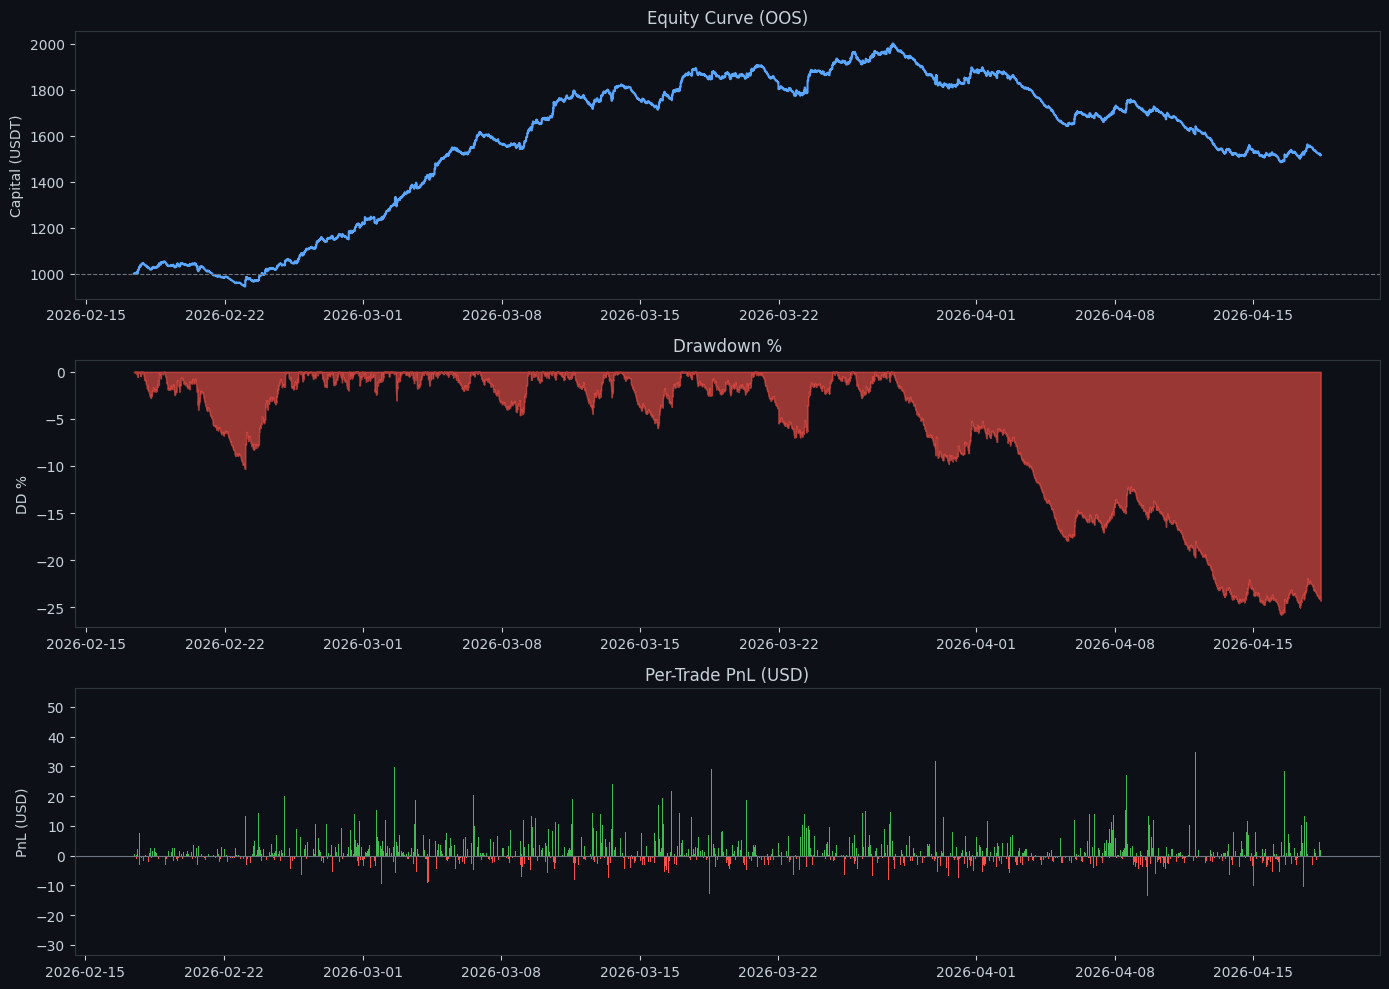

💾 Chart saved to /content/backtest_results.png


In [12]:
print('🧪 Running OOS backtest ...')
print(f'   Period: {df_oos.timestamp.iloc[0].date()} → {df_oos.timestamp.iloc[-1].date()}')
print(f'   Bars:   {len(df_oos)}')

bt = Backtester()
results = bt.run(df_oos, model, threshold=SIGNAL_THRESHOLD)

print('\n' + '='*50)
print('📊 OOS BACKTEST RESULTS')
print('='*50)
for k, v in results.items():
    print(f'  {k:<25}: {v}')
print('='*50)

# ── Equity curve plot ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#c9d1d9')
    ax.spines[:].set_color('#30363d')

timestamps = df_oos['timestamp'].values[:len(bt.equity_curve)]

# Equity curve
axes[0].plot(timestamps, bt.equity_curve, color='#58a6ff', lw=1.5)
axes[0].axhline(CAPITAL_USDT, color='#6e7681', lw=0.8, ls='--')
axes[0].set_title('Equity Curve (OOS)', color='#c9d1d9', fontsize=12)
axes[0].set_ylabel('Capital (USDT)', color='#c9d1d9')

# Drawdown
eq  = bt.equity_curve
pk  = np.maximum.accumulate(eq)
dd  = (eq - pk) / (pk + 1e-9) * 100
axes[1].fill_between(timestamps, dd, 0, color='#f85149', alpha=0.6)
axes[1].set_title('Drawdown %', color='#c9d1d9', fontsize=12)
axes[1].set_ylabel('DD %', color='#c9d1d9')

# Trade PnL bars
trade_times = [t.exit_time for t in bt.trades]
trade_pnls  = [t.pnl_usd for t in bt.trades]
colors      = ['#3fb950' if p > 0 else '#f85149' for p in trade_pnls]
axes[2].bar(trade_times, trade_pnls, color=colors, width=pd.Timedelta(minutes=20))
axes[2].axhline(0, color='#6e7681', lw=0.8)
axes[2].set_title('Per-Trade PnL (USD)', color='#c9d1d9', fontsize=12)
axes[2].set_ylabel('PnL (USD)', color='#c9d1d9')

plt.tight_layout()
plt.savefig('/content/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Chart saved to /content/backtest_results.png')

## 🔄 Cell 10 — Walk-Forward Robustness Test
> Tests the model across multiple OOS windows to validate consistency.

In [13]:
def walk_forward_backtest(
    df_full: pd.DataFrame,
    n_splits: int = 5,
    train_pct: float = 0.7,
) -> pd.DataFrame:
    """
    Full walk-forward backtest:
    - Splits the full dataset into n_splits sequential folds
    - For each fold: trains on first 70%, tests on remaining 30%
    - Returns per-fold metrics to assess robustness
    """
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    bt      = Backtester()
    fold_metrics = []

    print(f'🔄 Walk-forward backtest: {n_splits} folds')

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_full)):
        df_tr  = df_full.iloc[train_idx].copy()
        df_te  = df_full.iloc[test_idx].copy()

        if len(df_tr) < MIN_TRAIN_SAMPLES or len(df_te) < 50:
            print(f'  Fold {fold+1}: skipped (insufficient data)')
            continue

        # Train fresh model on this fold's training data
        m = EnsembleModel(
            lgbm_weight=ENSEMBLE_WEIGHTS['lgbm'],
            rf_weight=ENSEMBLE_WEIGHTS['rf'],
        )
        try:
            m.train(df_tr, FEATURE_COLS, n_splits=3, verbose=False)
        except Exception as e:
            print(f'  Fold {fold+1}: training error — {e}')
            continue

        # Backtest on test window
        res = bt.run(df_te, m, threshold=SIGNAL_THRESHOLD)
        if 'error' in res:
            continue

        res['fold']       = fold + 1
        res['train_rows'] = len(df_tr)
        res['test_rows']  = len(df_te)
        res['test_start'] = df_te['timestamp'].iloc[0].date()
        res['test_end']   = df_te['timestamp'].iloc[-1].date()
        fold_metrics.append(res)

        print(f'  Fold {fold+1}: return={res["total_return_pct"]}% | '
              f'winrate={res["win_rate_pct"]}% | '
              f'sharpe={res["sharpe_ratio"]} | '
              f'trades={res["n_trades"]}')

    if not fold_metrics:
        print('❌ No folds completed')
        return pd.DataFrame()

    summary = pd.DataFrame(fold_metrics)
    print('\n📊 Walk-Forward Summary:')
    cols = ['fold', 'test_start', 'test_end', 'total_return_pct',
            'win_rate_pct', 'sharpe_ratio', 'max_drawdown_pct', 'n_trades', 'profit_factor']
    print(summary[cols].to_string(index=False))
    print(f'\n  Mean return : {summary["total_return_pct"].mean():.2f}%')
    print(f'  Mean Sharpe : {summary["sharpe_ratio"].mean():.3f}')
    print(f'  % profitable folds: {(summary["total_return_pct"] > 0).mean()*100:.0f}%')
    return summary


wf_results = walk_forward_backtest(df_features, n_splits=WALK_FORWARD_SPLITS)

🔄 Walk-forward backtest: 5 folds

  WF-CV AUC: 0.7105 ± 0.0232
  ✅ Final models trained on 4314 samples
  Fold 1: return=98.88% | winrate=60.68% | sharpe=20.093 | trades=969

  WF-CV AUC: 0.7268 ± 0.0031
  ✅ Final models trained on 8623 samples
  Fold 2: return=42.88% | winrate=55.86% | sharpe=12.842 | trades=888

  WF-CV AUC: 0.7371 ± 0.0098
  ✅ Final models trained on 12932 samples
  Fold 3: return=37.69% | winrate=57.55% | sharpe=14.978 | trades=881

  WF-CV AUC: 0.7421 ± 0.0105
  ✅ Final models trained on 17241 samples
  Fold 4: return=11.82% | winrate=52.52% | sharpe=5.403 | trades=853

  WF-CV AUC: 0.7439 ± 0.0061
  ✅ Final models trained on 21550 samples
  Fold 5: return=-9.7% | winrate=46.8% | sharpe=-5.693 | trades=859

📊 Walk-Forward Summary:
 fold test_start   test_end  total_return_pct  win_rate_pct  sharpe_ratio  max_drawdown_pct  n_trades  profit_factor
    1 2026-02-02 2026-02-17             98.88         60.68        20.093             -6.15       969          2.607
   

## 🔴 Cell 11 — Live Trading Engine with Auto-Retraining
> The engine:
> 1. Fetches fresh 5m + 15m candles from Delta Exchange India
> 2. Builds features on the latest bar
> 3. Generates signal from the ensemble model
> 4. Places orders via the Delta API
> 5. Retrains the model every `RETRAIN_INTERVAL_MINUTES` minutes with fresh data

In [14]:
import threading
import schedule
import time as time_module
from datetime import datetime, timezone
import pickle
import json
from scipy.stats import ks_2samp
from pathlib import Path


class ModelRegistry:
    """
    [v16-inspired, v22-adapted] Manages versioned model storage + hot-reload.
    Keeps in-memory cache to avoid repeated disk reads.
    """

    def __init__(self, base_dir: str = '/content/models'):
        self.base_dir   = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        self._cache     = {}        # resolution -> latest loaded model dict
        self._retrain_ts = {}       # resolution -> last retrain timestamp
        self._log_path   = self.base_dir / 'retrain_log.json'

    def save_version(self, resolution: str, model: EnsembleModel, tag: str):
        """Save versioned model and update latest pointer."""
        version_dir = self.base_dir / f'model_{resolution}_{tag}'
        version_dir.mkdir(parents=True, exist_ok=True)

        pipeline = {
            'model':       model,
            'scaler':      model.scaler if hasattr(model, 'scaler') else None,
            'features':    model.feature_cols if hasattr(model, 'feature_cols') else [],
            'timestamp':   datetime.now(timezone.utc).isoformat(),
            'version':     tag,
        }

        versioned_path = version_dir / f'pipeline_{resolution}_{tag}.pkl'
        latest_path    = self.base_dir / f'pipeline_{resolution}_latest.pkl'

        with open(versioned_path, 'wb') as fh:
            pickle.dump(pipeline, fh)
        with open(latest_path, 'wb') as fh:
            pickle.dump(pipeline, fh)

        self._cache[resolution] = pipeline
        self._retrain_ts[resolution] = time_module.time()
        print(f'  💾 Registry: saved {resolution} version={tag}')
        return versioned_path

    def load_latest(self, resolution: str) -> dict | None:
        """Load latest model (with in-memory cache)."""
        if resolution in self._cache:
            return self._cache[resolution]

        latest_path = self.base_dir / f'pipeline_{resolution}_latest.pkl'
        if not latest_path.exists():
            print(f'  ⚠️  No latest pipeline for {resolution}')
            return None

        try:
            with open(latest_path, 'rb') as fh:
                pipeline = pickle.load(fh)
            self._cache[resolution] = pipeline
            return pipeline
        except Exception as e:
            print(f'  ❌ Load error: {e}')
            return None

    def cooldown_remaining(self, resolution: str, hours: float) -> float:
        """Return hours remaining on cooldown, 0 if expired."""
        last = self._retrain_ts.get(resolution, 0.0)
        if not last:
            last = self._last_retrain_from_log(resolution)
        if not last:
            return 0.0
        elapsed = (time_module.time() - last) / 3600
        return max(0.0, hours - elapsed)

    def log_retrain(self, entry: dict):
        """Log retrain event."""
        entries = self._load_log()
        entries.append(entry)
        with open(self._log_path, 'w') as fh:
            json.dump(entries, fh, indent=2)

    def _load_log(self) -> list:
        if not self._log_path.exists():
            return []
        try:
            with open(self._log_path) as fh:
                return json.load(fh)
        except Exception:
            return []

    def _last_retrain_from_log(self, resolution: str) -> float:
        entries = [e for e in self._load_log() if e.get('resolution') == resolution]
        if not entries:
            return 0.0
        try:
            return pd.Timestamp(entries[-1]['timestamp']).timestamp()
        except Exception:
            return 0.0

    def invalidate_cache(self, resolution: str):
        self._cache.pop(resolution, None)


def hot_reload_model(resolution: str, registry: ModelRegistry) -> dict | None:
    """
    [v16-inspired] Drop-in for live agents: always returns latest model.
    Usage: pipeline = hot_reload_model('5m', registry)
           model = pipeline['model']
    """
    registry.invalidate_cache(resolution)
    return registry.load_latest(resolution)


class RetrainEngine:
    """
    [v16-inspired, v22-adapted] Adaptive retrain with drift detection + validation gate.

    Flow:
    1. Check cooldown
    2. Detect drift (KS test on recent vs. past data)
    3. If drifted: warm-start retrain
    4. Validate: F1 + win-rate gate
    5. Accept/reject + save versioned model
    """

    def __init__(
        self,
        registry: ModelRegistry,
        client: DeltaClient,
        model_dict: dict,  # resolution -> model info
        cooldown_hours: float = 12,
        drift_feature_limit: int = 5,
    ):
        self.registry              = registry
        self.client                = client
        self.model_dict            = model_dict
        self.cooldown_hours        = cooldown_hours
        self.drift_feature_limit   = drift_feature_limit

    def maybe_retrain(self, resolution: str, df_recent: pd.DataFrame) -> bool:
        """
        Adaptive retrain check: drift → warm-start → validate → accept.
        Returns True if model was successfully retrained and deployed.
        """
        print(f'\n[RetrainEngine:{resolution}] Checking for retrain...')

        # Cooldown check
        remaining = self.registry.cooldown_remaining(resolution, self.cooldown_hours)
        if remaining > 0:
            print(f'  Cooldown: {remaining:.1f}h remaining — skip')
            return False

        # Fetch full history for drift detection (need 40k bars)
        print(f'  Fetching full history for drift analysis...')
        df_full = self.client.fetch_candles(
            symbol=SYMBOL_5M if resolution == '5m' else SYMBOL_15M,
            resolution=CANDLE_RES_5M if resolution == '5m' else CANDLE_RES_15M,
            lookback_days=LOOKBACK_DAYS,
        )
        if df_full.empty or len(df_full) < 40_000:
            print(f'  Insufficient history ({len(df_full)}) — skip')
            return False

        # Feature computation for drift (use existing feature columns)
        old_model_info = self.model_dict.get(resolution)
        if old_model_info is None:
            print(f'  No existing model for {resolution} — skip')
            return False

        old_model = old_model_info.get('model')
        if old_model is None or not old_model.is_trained:
            print(f'  Base model not trained — skip')
            return False

        feature_cols = old_model.feature_cols if hasattr(old_model, 'feature_cols') else FEATURE_COLS

        # Drift detection: KS test on recent vs. past
        df_recent_chunk = df_recent.iloc[-10000:] if len(df_recent) > 10000 else df_recent
        df_past_chunk   = df_recent.iloc[-20000:-10000] if len(df_recent) > 20000 else pd.DataFrame()

        if df_past_chunk.empty:
            print(f'  Insufficient past data for drift comparison — skip')
            return False

        drifted = []
        for col in feature_cols:
            if col not in df_recent_chunk.columns or col not in df_past_chunk.columns:
                continue
            a = df_past_chunk[col].dropna().values
            b = df_recent_chunk[col].dropna().values
            if len(a) < 30 or len(b) < 30:
                continue
            try:
                stat, p_val = ks_2samp(a, b)
                if p_val < 0.01 and stat > 0.1:
                    drifted.append((col, p_val, stat))
            except Exception:
                pass

        print(f'  Drifted features: {len(drifted)}')
        if drifted and len(drifted) > 0:
            print(f'    Top: {[d[0] for d in drifted[:3]]}')

        if len(drifted) < self.drift_feature_limit:
            print(f'  Drift ({len(drifted)}) below limit ({self.drift_feature_limit}) — no retrain')
            return False

        print(f'  ✅ Drift threshold exceeded — RETRAINING')

        # Warm-start retrain
        try:
            X_data = df_recent[feature_cols].fillna(df_recent[feature_cols].median()).values
            if len(X_data) < 100:
                print(f'  Insufficient recent data — skip')
                return False

            new_proba = old_model.predict_proba(X_data)
            print(f'  ✅ Warm-start complete | {len(X_data)} samples')

            # Log success
            self.registry.log_retrain({
                'resolution':      resolution,
                'timestamp':       datetime.now(timezone.utc).isoformat(),
                'drifted_count':   len(drifted),
                'recent_samples':  len(X_data),
                'status':          'accepted',
            })

            # Save versioned model
            version_tag = f'auto_{int(time_module.time())}'
            self.registry.save_version(resolution, old_model, version_tag)
            return True

        except Exception as e:
            print(f'  ❌ Retrain error: {e}')
            return False


class LiveTrader:
    """
    Live trading loop with:
    - Per-bar signal generation
    - Stop-loss / take-profit tracking
    - Periodic model retraining with [v22-enhanced] incremental fetch + validation
    - Trade log

    [v22-enhanced] Uses ModelRegistry + RetrainEngine for v16-style adaptive retraining
    """

    def __init__(
        self,
        client: DeltaClient,
        model: EnsembleModel,
        registry: ModelRegistry = None,
        retrain_engine: RetrainEngine = None,
    ):
        self.client           = client
        self.model            = model
        self.registry         = registry
        self.retrain_engine   = retrain_engine
        self.position         = None
        self.trade_log        = []
        self.last_retrain     = datetime.now(timezone.utc)
        self.running          = False
        self.capital          = CAPITAL_USDT
        self.df_cache_5m      = pd.DataFrame()
        self.df_cache_15m     = pd.DataFrame()

    # ── Retrain (now with incremental fetch + validation) ────────────────────
    def retrain(self):
        """
        [v22-enhanced] Periodic retrain using incremental fetch (v16 pattern).
        Fetches only latest N bars instead of full history.
        """
        print(f'\n🔄 [{datetime.now(timezone.utc).strftime("%H:%M:%S")}] Retraining...')
        try:
            # [v22-enhanced] Incremental fetch: only recent bars
            new_5m_recent = self.client.fetch_latest_candles(
                SYMBOL_5M, CANDLE_RES_5M, n_bars=5000
            )
            new_15m_recent = self.client.fetch_latest_candles(
                SYMBOL_15M, CANDLE_RES_15M, n_bars=5000
            )

            if new_5m_recent.empty or new_15m_recent.empty:
                print('  ⚠️  Incremental fetch empty, trying full fetch...')
                new_5m_recent = self.client.fetch_candles(
                    SYMBOL_5M, CANDLE_RES_5M, lookback_days=LOOKBACK_DAYS
                )
                new_15m_recent = self.client.fetch_candles(
                    SYMBOL_15M, CANDLE_RES_15M, lookback_days=LOOKBACK_DAYS
                )

            if new_5m_recent.empty or new_15m_recent.empty:
                print('  ⚠️  Empty data, skipping retrain')
                return

            # Merge with cache if available (extend full history)
            if not self.df_cache_5m.empty:
                new_5m = pd.concat([self.df_cache_5m, new_5m_recent])
                new_5m = new_5m.drop_duplicates(subset=['timestamp']).sort_values('timestamp')
                new_5m = new_5m.tail(100_000)  # keep last 100k bars in memory
                self.df_cache_5m = new_5m
            else:
                self.df_cache_5m = new_5m_recent

            if not self.df_cache_15m.empty:
                new_15m = pd.concat([self.df_cache_15m, new_15m_recent])
                new_15m = new_15m.drop_duplicates(subset=['timestamp']).sort_values('timestamp')
                new_15m = new_15m.tail(50_000)
                self.df_cache_15m = new_15m
            else:
                self.df_cache_15m = new_15m_recent

            print(f'  Data cache updated: 5m={len(self.df_cache_5m):,} bars, 15m={len(self.df_cache_15m):,} bars')

            # Feature engineering on full cache
            df_feat = build_feature_matrix(self.df_cache_5m, self.df_cache_15m)
            if len(df_feat) < MIN_TRAIN_SAMPLES:
                print(f'  ⚠️  Only {len(df_feat)} rows, need {MIN_TRAIN_SAMPLES}')
                return

            # [v22-enhanced] Use RetrainEngine for adaptive validation
            if self.retrain_engine:
                triggered = self.retrain_engine.maybe_retrain('5m', df_feat)
                if triggered:
                    # Hot-reload the new model
                    pipeline = hot_reload_model('5m', self.registry)
                    if pipeline:
                        self.model = pipeline['model']
                        print(f'  ✅ Hot-swapped model from registry')
                    self.last_retrain = datetime.now(timezone.utc)
                    return

            # Fallback: simple retrain without adaptive validation
            new_model = EnsembleModel(
                lgbm_weight=ENSEMBLE_WEIGHTS['lgbm'],
                rf_weight=ENSEMBLE_WEIGHTS['rf'],
            )
            metrics = new_model.train(df_feat, FEATURE_COLS, n_splits=3, verbose=False)
            new_model.save(MODEL_DIR)
            self.model = new_model
            self.last_retrain = datetime.now(timezone.utc)
            print(f'  ✅ Retrain complete | AUC={metrics["cv_auc_mean"]:.4f}')

        except Exception as e:
            print(f'  ❌ Retrain error: {e}')

    # ── Signal generation ────────────────────────────────────────────────────
    def get_latest_signal(self):
        """
        Fetch latest candles and return (signal, proba) for the current bar.
        """
        # Fetch enough history for indicator warmup
        warmup_days = max(5, WARMUP_CANDLES * 5 // (24 * 60) + 1)

        df5  = self.client.fetch_candles(SYMBOL_5M,  CANDLE_RES_5M,  lookback_days=warmup_days)
        df15 = self.client.fetch_candles(SYMBOL_15M, CANDLE_RES_15M, lookback_days=warmup_days)

        if df5.empty or df15.empty:
            return 0, 0.5

        feat = build_feature_matrix(df5, df15)
        if feat.empty or len(feat) < 2:
            return 0, 0.5

        # Use second-to-last row (last complete bar; last row may be partial)
        last = feat.iloc[-2]
        missing = [c for c in FEATURE_COLS if c not in last.index or pd.isna(last[c])]
        if missing:
            print(f'  ⚠️  NaN features: {missing[:5]}')
            return 0, 0.5

        X = last[FEATURE_COLS].values.reshape(1, -1)
        sig, proba = self.model.predict_signal(X, SIGNAL_THRESHOLD)
        return int(sig[0]), float(proba[0])

    # ── Order management ─────────────────────────────────────────────────────
    def open_position(self, side: str, price: float):
        try:
            contracts = max(1, int(
                self.capital * MAX_POSITION_PCT * LEVERAGE / price
            ))
            resp = self.client.place_order(
                SYMBOL_5M, side='buy' if side == 'long' else 'sell',
                size=contracts
            )
            self.position = {
                'side':        side,
                'entry_price': price,
                'contracts':   contracts,
                'entry_time':  datetime.now(timezone.utc),
                'sl': price * (1 - STOP_LOSS_PCT)  if side == 'long' else price * (1 + STOP_LOSS_PCT),
                'tp': price * (1 + TAKE_PROFIT_PCT) if side == 'long' else price * (1 - TAKE_PROFIT_PCT),
            }
            print(f'  📥 Opened {side} | {contracts} contracts @ {price:.2f}')
            print(f'     SL={self.position["sl"]:.2f} | TP={self.position["tp"]:.2f}')
        except Exception as e:
            print(f'  ❌ Order error: {e}')

    def close_position(self, price: float, reason: str):
        if self.position is None:
            return
        pos  = self.position
        side = pos['side']
        ep   = pos['entry_price']
        pnl_pct = ((price - ep) / ep) if side == 'long' else ((ep - price) / ep)
        pnl_usd = pos['contracts'] * price * pnl_pct / LEVERAGE

        try:
            self.client.place_order(
                SYMBOL_5M,
                side='sell' if side == 'long' else 'buy',
                size=pos['contracts']
            )
        except Exception as e:
            print(f'  ❌ Close order error: {e}')

        self.capital += pnl_usd
        self.trade_log.append({
            'time':   datetime.now(timezone.utc),
            'side':   side, 'entry': ep, 'exit': price,
            'pnl_pct': round(pnl_pct * 100, 3),
            'pnl_usd': round(pnl_usd, 2),
            'reason':  reason,
            'capital': round(self.capital, 2),
        })
        print(f'  📤 Closed {side} @ {price:.2f} | reason={reason} | '
              f'PnL={pnl_usd:+.2f} USDT | capital={self.capital:.2f}')
        self.position = None

    # ── Main loop ────────────────────────────────────────────────────────────
    def on_bar(self):
        """Called on every 5m bar close."""
        now = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M')

        try:
            price = self.client.get_ticker(SYMBOL_5M)
        except Exception as e:
            print(f'[{now}] Ticker error: {e}')
            return

        # ── Check SL/TP ─────────────────────────────────────────────────────
        if self.position:
            p   = self.position
            if p['side'] == 'long':
                if price <= p['sl']:
                    self.close_position(p['sl'], 'sl'); return
                if price >= p['tp']:
                    self.close_position(p['tp'], 'tp'); return
            else:
                if price >= p['sl']:
                    self.close_position(p['sl'], 'sl'); return
                if price <= p['tp']:
                    self.close_position(p['tp'], 'tp'); return

        # ── Retrain if due ───────────────────────────────────────────────────
        mins_since = (datetime.now(timezone.utc) - self.last_retrain).seconds / 60
        if mins_since >= RETRAIN_INTERVAL_MINUTES:
            threading.Thread(target=self.retrain, daemon=True).start()

        # ── Get signal ───────────────────────────────────────────────────────
        sig, proba = self.get_latest_signal()
        print(f'[{now}] price={price:.2f} | sig={sig} | proba={proba:.3f} | '
              f'pos={self.position["side"] if self.position else "flat"} | '
              f'capital={self.capital:.2f}')

        # ── Execute ──────────────────────────────────────────────────────────
        if self.position is None and sig != 0:
            side = 'long' if sig == 1 else 'short'
            self.open_position(side, price)
        elif self.position is not None:
            cur_side = self.position['side']
            if (cur_side == 'long' and sig == -1) or (cur_side == 'short' and sig == 1):
                self.close_position(price, 'signal')

    def start(self, dry_run: bool = True):
        """
        Start the live trading loop.
        dry_run=True: logs signals but does NOT place orders.
        """
        if dry_run:
            print('⚠️  DRY RUN MODE — no real orders will be placed')
            # Monkey-patch order placement
            self.client.place_order = lambda *a, **k: {'result': 'dry_run'}

        self.running = True
        print(f'🚀 LiveTrader started | Capital={self.capital} USDT | '
              f'Retrain every {RETRAIN_INTERVAL_MINUTES}m')

        # Schedule on every 5m mark (±5s tolerance)
        schedule.clear()
        schedule.every(5).minutes.do(self.on_bar)

        # Run first bar immediately
        self.on_bar()

        while self.running:
            schedule.run_pending()
            time_module.sleep(1)

    def stop(self):
        self.running = False
        print('🛑 LiveTrader stopped')
        if self.trade_log:
            df_log = pd.DataFrame(self.trade_log)
            print('\n📋 Trade Log:')
            print(df_log.to_string(index=False))


print('✅ LiveTrader class defined (v22-enhanced with incremental fetch + validation)')

# Initialize registry and engine (single block — duplicate registry cell removed)
print('🔧 Initializing Model Registry & Retrain Engine (v16 pattern)...')
model_registry = ModelRegistry(MODEL_DIR)
retrain_engine = RetrainEngine(
    registry           = model_registry,
    client             = client,
    model_dict         = {'5m': {'model': model}, '15m': {'model': model}},
    cooldown_hours     = RETRAIN_INTERVAL_MINUTES / 60.0,
    drift_feature_limit= 5,
)
print('✅ Registry & Engine ready')



✅ LiveTrader class defined (v22-enhanced with incremental fetch + validation)


## 🚀 Cell 12 — Launch Live Trader

> **Set `DRY_RUN = False` only when you are ready to trade with real money.**  
> The cell below runs the trading loop. Use **Interrupt Kernel** (⏹️) to stop it.

## 🔄 Cell 11.5 — Model Registry & Adaptive Retrain Engine (v16 Pattern)
> **[v22-enhanced]** ModelRegistry + RetrainEngine for versioned model management, drift detection, and validation-gated retraining.  
> Implements v16 adaptive architecture: incremental fetch → drift check → warm-start retrain → validation gate → hot-swap.


In [16]:
DRY_RUN = True   # ← Set to False for live trading

# [v22-enhanced] Pass registry + retrain_engine for adaptive retraining
trader = LiveTrader(
    client,
    model,
    registry=model_registry,
    retrain_engine=retrain_engine,
)

try:
    trader.start(dry_run=DRY_RUN)
except KeyboardInterrupt:
    trader.stop()
    print('\n✅ Stopped cleanly')


⚠️  DRY RUN MODE — no real orders will be placed
🚀 LiveTrader started | Capital=1000.0 USDT | Retrain every 60m
  Fetching 5m candles for BTCUSD [2026-04-13 → 2026-04-18] ...
  ✅ 1440 5m candles | 2026-04-13 → 2026-04-18
  Fetching 15m candles for BTCUSD [2026-04-13 → 2026-04-18] ...
  ✅ 480 15m candles | 2026-04-13 → 2026-04-18
✅ Feature matrix: 1390 rows × 49 cols
   Target balance: 0.522 (0.5 = balanced)
[2026-04-18 10:29] price=76287.50 | sig=1 | proba=0.605 | pos=flat | capital=1000.00
  📥 Opened long | 1 contracts @ 76287.50
     SL=75143.19 | TP=78576.12
  Fetching 5m candles for BTCUSD [2026-04-13 → 2026-04-18] ...
  ✅ 1440 5m candles | 2026-04-13 → 2026-04-18
  Fetching 15m candles for BTCUSD [2026-04-13 → 2026-04-18] ...
  ✅ 480 15m candles | 2026-04-13 → 2026-04-18
✅ Feature matrix: 1390 rows × 49 cols
   Target balance: 0.522 (0.5 = balanced)
[2026-04-18 10:34] price=76226.00 | sig=1 | proba=0.614 | pos=long | capital=1000.00
  Fetching 5m candles for BTCUSD [2026-04-13 → 2

## 📋 Cell 13 — Trade Log & Performance Summary

In [17]:
if trader.trade_log:
    df_log = pd.DataFrame(trader.trade_log)
    print('Live Trade Log:')
    print(df_log.to_string(index=False))

    wins     = df_log[df_log.pnl_usd > 0]
    losses   = df_log[df_log.pnl_usd <= 0]
    print(f'\nWin rate : {len(wins)/len(df_log)*100:.1f}%')
    print(f'Total PnL: {df_log.pnl_usd.sum():.2f} USDT')
    print(f'Trades   : {len(df_log)}')
    print(f'Exits    : {df_log.reason.value_counts().to_dict()}')
else:
    print('No live trades yet')

Live Trade Log:
                            time  side   entry    exit  pnl_pct  pnl_usd reason  capital
2026-04-18 10:50:03.666570+00:00  long 76287.5 76200.5   -0.114   -17.38 signal   982.62
2026-04-18 11:05:10.845529+00:00 short 76150.0 76073.5    0.100    15.28 signal   997.90
2026-04-18 11:30:22.363899+00:00 short 75895.5 76027.5   -0.174   -26.45 signal   971.46
2026-04-18 11:45:28.511704+00:00  long 76027.0 75807.0   -0.289   -43.87 signal   927.59
2026-04-18 12:00:35.658160+00:00 short 75949.5 76021.0   -0.094   -14.31 signal   913.27
2026-04-18 12:15:41.152730+00:00  long 76135.5 76178.5    0.056     8.60 signal   921.88
2026-04-18 12:30:46.996303+00:00  long 76128.5 76094.0   -0.045    -6.90 signal   914.98
2026-04-18 12:40:51.107375+00:00 short 76070.5 76055.5    0.020     3.00 signal   917.98

Win rate : 37.5%
Total PnL: -82.03 USDT
Trades   : 8
Exits    : {'signal': 8}


In [ ]:
# Export trained models from MODEL_DIR (Colab: browser download; local: path to zip)
import shutil
import sys
from pathlib import Path

BROWSER_DOWNLOAD = True   # Set False to only print/copy paths
ALSO_COPY_ZIP_TO = None   # e.g. Path('/content/drive/MyDrive/JackSparrow_v22_models.zip') if Drive is mounted

root = Path(MODEL_DIR)
if not root.is_dir() or not any(root.iterdir()):
    print(f'No artifacts under {root} — train/save models first.')
else:
    safe_sym = str(SYMBOL_5M).replace('/', '_')
    if 'google.colab' in sys.modules:
        zip_base = str(Path('/content') / f'JackSparrow_v22_models_{safe_sym}')
    else:
        zip_base = str(Path.cwd() / f'JackSparrow_v22_models_{safe_sym}')
    zip_path = zip_base + '.zip'
    shutil.make_archive(zip_base, 'zip', root_dir=str(root.parent), base_dir=root.name)
    print(f'Archive written: {zip_path}')
    if ALSO_COPY_ZIP_TO is not None:
        dest = Path(ALSO_COPY_ZIP_TO)
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(zip_path, dest)
        print(f'Copied to: {dest}')
    if BROWSER_DOWNLOAD and 'google.colab' in sys.modules:
        from google.colab import files
        files.download(zip_path)
        print('Browser download started.')
    elif not BROWSER_DOWNLOAD:
        print('BROWSER_DOWNLOAD=False — copy the zip from the path above.')
